# Marketplace Customer Analytics

Customer-level analysis of an e-commerce marketplace: 62,408 customer-region
records covering 62,400 customers in the three highest-volume regions, built
from 99k orders, 113k order items, 104k payments and 78k reviews.

Every stated difference is tested. Ratio metrics such as average order value are
compared with the delta method at the customer level, proportions with a
chi-squared test of homogeneity, and multi-group comparisons are Holm-corrected.
Order value has a heavy right tail (skewness 10.2, excess kurtosis 308,
max/mean 87), so every conclusion drawn from a mean is also checked against a
P99-winsorized version and a rank test.

## Findings

1. Moscow's average order value is significantly below both other regions
   (-14.3% vs Saint Petersburg, -11.0% vs Novosibirsk region). Saint Petersburg
   and Novosibirsk region are indistinguishable from each other (p = 0.12).
2. One-order customers have a higher order-weighted average order cost than
   repeat customers but a lower median one. Both effects are significant and
   opposite; the reversal is driven by one-off large purchases.
3. Purchase frequency and average order value are unrelated among customers with
   three or more orders (Spearman rho = 0.087, p = 0.28, n = 155).
4. Average order value shifts up 13% for cohorts acquired from September 2023
   onwards. It is a level shift, not monthly seasonality: all 16 pairwise
   differences surviving Holm correction cross the August-September boundary.
5. The apparent decline in customer activity duration across cohorts is entirely
   an artifact of unequal observation windows. In a fixed 30-day window, repeat
   purchase rates do not differ across cohorts (p = 0.75).
6. Average review score drops in Q4 (4.32 in August to 4.01 in November,
   p = 2e-19) exactly when acquisition and order value peak.

## Contents

1. Setup and data
2. Customer segmentation (adhoc01)
3. Customer ranking by AOV (adhoc02)
4. Regional analysis (adhoc03)
5. Cohort analysis by first order month (adhoc04)
6. Limitations

In [74]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
from scipy import stats

# GitHub strips JavaScript from rendered notebooks, so Plotly figures are
# exported as static PNG for the README and rendered inline via nbviewer.
pio.renderers.default = "notebook_connected"

RNG = np.random.default_rng(42)

In [75]:
def ratio_metric(df, num, den):
    """
    Ratio metric R = sum(num) / sum(den) with delta-method variance, treating
    the customer as the unit of observation.

    The naive variance of a ratio understates uncertainty because numerator and
    denominator are correlated across customers: a customer with more orders
    contributes to both. The delta method linearizes R around the means and
    keeps the covariance term.
    """
    x = df[num].fillna(0).to_numpy(dtype=float)
    y = df[den].to_numpy(dtype=float)
    n = len(df)
    my = y.mean()
    R = x.mean() / my
    cov = np.cov(x, y, ddof=1)
    var = (cov[0, 0] - 2 * R * cov[0, 1] + R * R * cov[1, 1]) / (n * my * my)
    return R, var, n


def compare_ratio(df_a, df_b, num, den):
    """Two-sided z-test for the difference of two ratio metrics."""
    Ra, Va, _ = ratio_metric(df_a, num, den)
    Rb, Vb, _ = ratio_metric(df_b, num, den)
    z = (Ra - Rb) / np.sqrt(Va + Vb)
    return Ra, Rb, z, 2 * stats.norm.sf(abs(z))


def homogeneity_test(estimates, variances):
    """
    Chi-squared test that a set of independent ratio estimates share a common
    value, using inverse-variance weighting.
    """
    est = np.asarray(estimates)
    w = 1 / np.asarray(variances)
    pooled = (w * est).sum() / w.sum()
    chi2 = (w * (est - pooled) ** 2).sum()
    dof = len(est) - 1
    return chi2, dof, stats.chi2.sf(chi2, dof)

In [76]:
customers = pd.read_csv("customer_features.csv")
customers["delivered_orders"] = (
    customers["total_orders"] - customers["num_canceled_orders"]
)

cohorts = pd.read_csv("first_order_cohort_export.csv")
cohorts["first_order_ts"] = pd.to_datetime(cohorts["first_order_ts"])
cohorts["cohort_month"] = cohorts["first_order_ts"].dt.to_period("M")
cohorts["delivered_orders"] = (
    cohorts["total_orders"] - cohorts["num_canceled_orders"]
)

regional = pd.read_csv("regional_statistics.csv")

print(customers.shape, customers["user_id"].nunique())
print(cohorts.shape, cohorts["user_id"].nunique())

(62408, 15) 62400
(27581, 12) 27577


In [77]:
fig = px.bar(
    regional.sort_values("total_users_region", ascending=True),
    x="total_users_region",
    y="region",
    orientation="h",
    title="Customer Base by Region",
    labels={
        "total_users_region": "Number of Customers",
        "region": "Region"
    },
    text="total_users_region"
)

fig.update_traces(textposition="outside")

fig.show()

In [78]:
fig.write_image(
    "../images/customer_base_by_region.png", width=1000, height=450, scale=2
)

In [79]:
fig = px.bar(
    regional.sort_values("aov_region", ascending=True),
    x="aov_region",
    y="region",
    orientation="h",
    title="Average Order Value (AOV) by Region",
    labels={
        "aov_region": "Average Order Value",
        "region": "Region"
    },
    text="aov_region"
)

fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")

fig.show()

In [80]:
fig = px.bar(
    regional.sort_values("installments_ratio", ascending=True),
    x="installments_ratio",
    y="region",
    orientation="h",
    title="Installment Usage by Region",
    labels={
        "installments_ratio": "Share of Orders with Installments",
        "region": "Region"
    },
    text="installments_ratio"
)

fig.update_traces(
    texttemplate="%{text:.2%}",
    textposition="inside"
)

fig.show()

In [81]:
fig = px.bar(
    regional.sort_values("promo_ratio", ascending=True),
    x="promo_ratio",
    y="region",
    orientation="h",
    title="Promo Code Usage by Region",
    labels={
        "promo_ratio": "Share of Orders with Promo Code",
        "region": "Region"
    },
    text="promo_ratio"
)

fig.update_traces(
    texttemplate="%{text:.2%}",
    textposition="inside"
)

fig.show()

In [82]:
fig = px.bar(
    regional.sort_values("cancel_ratio", ascending=True),
    x="cancel_ratio",
    y="region",
    orientation="h",
    title="Customer Cancellation Rate by Region",
    labels={
        "cancel_ratio": "Share of Customers with Cancelled Orders",
        "region": "Region"
    },
    text="cancel_ratio"
)

fig.update_traces(
    texttemplate="%{text:.2%}",
    textposition="inside"
)

fig.show()

In [83]:
regional.sort_values("total_users_region", ascending=False)

,region,total_users_region,orders_total_region,aov_region,installments_ratio,promo_ratio,cancel_ratio
0,Москва,39386,40747,3159.29,0.48,0.037,0.0063
1,Санкт-Петербург,11978,12414,3612.08,0.55,0.042,0.0053
2,Новосибирская область,11044,11401,3506.25,0.54,0.037,0.0043


In [84]:
regions = {r: g for r, g in customers.groupby("region")}

for a, b in [
    ("Санкт-Петербург", "Москва"),
    ("Новосибирская область", "Москва"),
    ("Санкт-Петербург", "Новосибирская область"),
]:
    Ra, Rb, z, p = compare_ratio(
        regions[a], regions[b], "total_order_costs", "delivered_orders"
    )
    print(f"{a} {Ra:.0f} vs {b} {Rb:.0f}: {Ra / Rb - 1:+.1%}, z = {z:.2f}, p = {p:.1e}")

Санкт-Петербург 3612 vs Москва 3159: +14.3%, z = 8.29, p = 1.1e-16
Новосибирская область 3506 vs Москва 3159: +11.0%, z = 6.95, p = 3.6e-12
Санкт-Петербург 3612 vs Новосибирская область 3506: +3.0%, z = 1.57, p = 1.2e-01


In [85]:
# The comparison that matters is also the least robust one, so it is repeated on
# a cluster bootstrap over customers.
def bootstrap_ratio_diff(df_a, df_b, num, den, n_iter=5000):
    xa, ya = df_a[num].fillna(0).to_numpy(), df_a[den].to_numpy(dtype=float)
    xb, yb = df_b[num].fillna(0).to_numpy(), df_b[den].to_numpy(dtype=float)
    out = np.empty(n_iter)
    for i in range(n_iter):
        ia = RNG.integers(0, len(xa), len(xa))
        ib = RNG.integers(0, len(xb), len(xb))
        out[i] = xa[ia].sum() / ya[ia].sum() - xb[ib].sum() / yb[ib].sum()
    return out


diff = bootstrap_ratio_diff(
    regions["Санкт-Петербург"],
    regions["Новосибирская область"],
    "total_order_costs",
    "delivered_orders",
)
print(f"95% CI: [{np.percentile(diff, 2.5):.0f}, {np.percentile(diff, 97.5):.0f}]")

95% CI: [-23, 233]


### Interpretation

**What the data shows.** Moscow's average order value is 3,159 against 3,612 in
Saint Petersburg (z = 8.29, p ~ 1e-16) and 3,506 in Novosibirsk region (z = 6.95,
p ~ 4e-12). Saint Petersburg and Novosibirsk region are not distinguishable from
each other: +3.0%, p = 0.12, bootstrap 95% CI for the difference [-25, +237]. All
three results are unchanged under P99 winsorization.

**What follows.** The finding is not that Saint Petersburg leads but that Moscow
lags, by 11-14% against both other regions while holding 63% of the customer
base. One point of AOV gained in Moscow is worth more than the same gain in the
other two regions combined. The hypothesis to test next is category mix: Moscow
may skew towards frequent low-value categories. That requires order-item level
data, which the mart does not carry, so the next step is extending it with a
category dimension and decomposing regional AOV into mix and within-category
price effects.

**Limitation.** Regions differ in size by a factor of three, so equal relative
differences are detected with unequal power; the SPb-Novosibirsk null result
means "not detected", not "no difference". Installment and promo shares are
order-weighted while the cancellation rate is customer-weighted, so the three
shares are not comparable to one another.

## Customer Activity by First Order Cohort

In [86]:
import pandas as pd

cohort_df = pd.read_csv(
    "first_order_cohort_analysis.csv"
)

cohort_df.head()

,month_of_2023,users_in_month,orders_in_month,aov_month,avg_order_rating_month,money_transfer_ratio_month,avg_first_to_last_order_days,repeat_within_30d_lower_bound
0,2023-01-01,465,499,2871.54,4.18,0.21,12.8,0.0280
1,2023-02-01,1063,1115,2574.48,4.17,0.22,7.0,0.0151
2,2023-03-01,1663,1762,2786.83,4.20,0.21,8.2,0.0174
3,2023-04-01,1435,1511,3161.71,4.15,0.19,7.1,0.0181
4,2023-05-01,2197,2322,2792.15,4.22,0.20,7.7,0.0173


In [87]:
cohort_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   month_of_2023                  12 non-null     str    
 1   users_in_month                 12 non-null     int64  
 2   orders_in_month                12 non-null     int64  
 3   aov_month                      12 non-null     float64
 4   avg_order_rating_month         12 non-null     float64
 5   money_transfer_ratio_month     12 non-null     float64
 6   avg_first_to_last_order_days   12 non-null     float64
 7   repeat_within_30d_lower_bound  12 non-null     float64
dtypes: float64(5), int64(2), str(1)
memory usage: 900.0 bytes


In [88]:
cohort_df["month_of_2023"] = pd.to_datetime(
    cohort_df["month_of_2023"]
)

In [89]:
cohort_df["month_label"] = cohort_df[
    "month_of_2023"
].dt.strftime("%b")

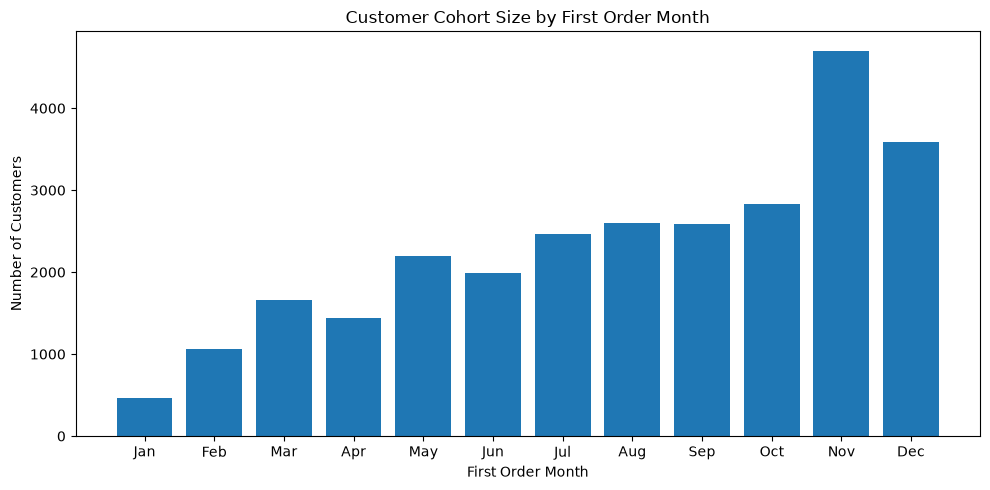

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    cohort_df["month_label"],
    cohort_df["users_in_month"]
)

plt.title("Customer Cohort Size by First Order Month")
plt.xlabel("First Order Month")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Interpretation

The size of customer cohorts varies substantially throughout 2023.
The January cohort is the smallest, while the November cohort is the largest,
indicating significant variation in customer acquisition dynamics across the year.

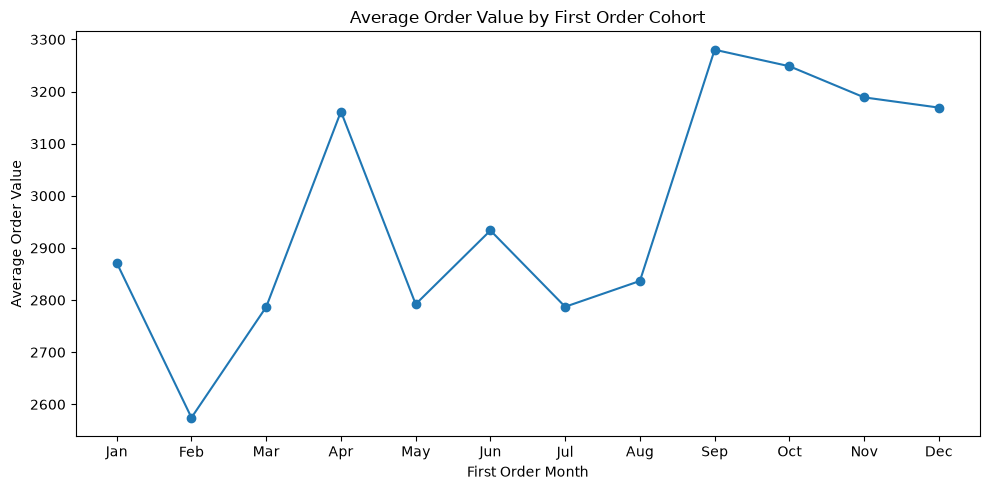

In [91]:
plt.figure(figsize=(10, 5))

plt.plot(
    cohort_df["month_label"],
    cohort_df["aov_month"],
    marker="o"
)

plt.title("Average Order Value by First Order Cohort")
plt.xlabel("First Order Month")
plt.ylabel("Average Order Value")

plt.tight_layout()
plt.show()

In [92]:
cohort_stats = {
    str(m): ratio_metric(g, "total_order_costs", "delivered_orders")
    for m, g in cohorts.groupby("cohort_month")
}
chi2, dof, p = homogeneity_test(
    [v[0] for v in cohort_stats.values()], [v[1] for v in cohort_stats.values()]
)
print(f"AOV homogeneity across 12 cohorts: chi2 = {chi2:.1f}, df = {dof}, p = {p:.1e}")

h2 = cohorts[cohorts["first_order_ts"].dt.month >= 9]
h1 = cohorts[cohorts["first_order_ts"].dt.month <= 8]
Ra, Rb, z, p = compare_ratio(h2, h1, "total_order_costs", "delivered_orders")
print(f"Sep-Dec {Ra:.0f} vs Jan-Aug {Rb:.0f}: {Ra / Rb - 1:+.1%}, z = {z:.2f}, p = {p:.1e}")

AOV homogeneity across 12 cohorts: chi2 = 79.4, df = 11, p = 1.9e-12
Sep-Dec 3214 vs Jan-Aug 2844: +13.0%, z = 6.94, p = 3.9e-12


### Interpretation

**What the data shows.** Cohorts do differ in average order value (chi2 = 79.4,
df = 11, p = 2e-12), but not month by month: September is indistinguishable from
October (p = 0.84), November (p = 0.54) and December (p = 0.46). After Holm
correction across all 66 pairs, 16 differences survive and every one of them
crosses the August-September boundary. The pattern is a level shift: 2,844 for
cohorts acquired January-August against 3,214 for September-December, +13.0%
(z = 6.94, p = 4e-12), and +11.9% after P99 winsorization.

**What follows.** Calling September the best month reads rank order out of noise.
The shift holds within each region separately (Moscow +9.7%, Novosibirsk region
+23.5%, Saint Petersburg +12.9%) and the regional composition of the two halves
is identical, so it is not a mix effect: something changed marketplace-wide in
the second half of 2023. Candidates the mart can distinguish once category and
price data are added: assortment change, price increase, or a shift in
acquisition channel. Cohort-level budget decisions belong on the half-year
split, not on the monthly ranking.

**Limitation.** Within January-August the cohorts are not perfectly homogeneous
(chi2 = 14.8, df = 7, p = 0.038), driven by April at 3,162; within
September-December they are (p = 0.81). The two-block description fits the
second half better than the first.

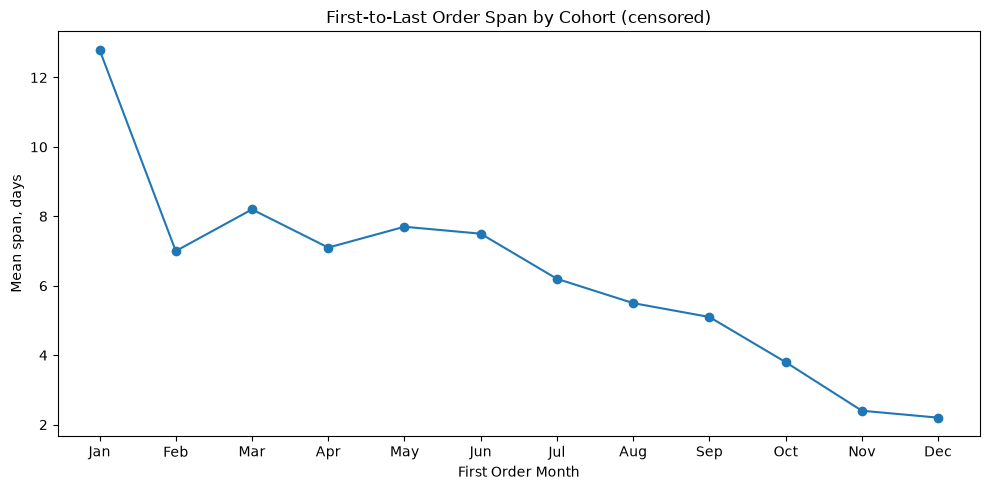

In [93]:
plt.figure(figsize=(10, 5))

plt.plot(
    cohort_df["month_label"],
    cohort_df["avg_first_to_last_order_days"],
    marker="o"
)

plt.title("First-to-Last Order Span by Cohort (censored)")
plt.xlabel("First Order Month")
plt.ylabel("Mean span, days")

plt.tight_layout()
plt.show()

In [94]:
WINDOW = 30
cohorts["repeat_30d"] = (
    (cohorts["total_orders"] > 1) & (cohorts["lifetime_days"] <= WINDOW)
).astype(int)

# Cohorts through November all have a complete 30-day window; December does not.
windowed = cohorts[cohorts["cohort_month"] <= pd.Period("2023-11")]
chi2_w, p_w, dof_w, _ = stats.chi2_contingency(
    pd.crosstab(windowed["cohort_month"], windowed["repeat_30d"])
)
chi2_r, p_r, dof_r, _ = stats.chi2_contingency(
    pd.crosstab(cohorts["cohort_month"], (cohorts["total_orders"] > 1).astype(int))
)

print(f"raw repeat rate: chi2 = {chi2_r:.1f}, df = {dof_r}, p = {p_r:.1e}")
print(f"30-day window:   chi2 = {chi2_w:.1f}, df = {dof_w}, p = {p_w:.2f}")

raw repeat rate: chi2 = 49.5, df = 11, p = 7.7e-07
30-day window:   chi2 = 6.8, df = 10, p = 0.75


### Interpretation

**What the data shows.** Raw first-to-last-order span falls from 12.8 days for
the January cohort to 2.2 for December, and the raw repeat purchase rate from
6.7% to 2.8% (chi2 = 49.5, df = 11, p < 1e-4). Both are artifacts. The data
effectively ends 2023-12-31, so the December cohort is observed for 17 days on
average against 341 for January. Measured in a fixed 30-day window, repeat
purchase rates across the January-November cohorts range from 1.5% to 2.8% with
no differences (chi2 = 6.8, df = 10, p = 0.75) and no trend (Spearman
rho = -0.12, p = 0.73).

**What follows.** Retention did not deteriorate over 2023; the metric did. Any
cohort dashboard built on the raw span will reproduce this false decline every
month and make recent acquisition look worse than it is. The reportable metric
is repeat purchase within a fixed window, with cohorts excluded until their
window closes. The raw metric is additionally degenerate: it is zero for the 96%
of cohort customers with a single order, so its average equals the repeat rate
times the mean span among repeat customers and cannot separate the two.

**Limitation.** The mart stores only first and last order timestamps, so a
repeat purchase inside the window is exactly identifiable for customers with
exactly two orders (90.7% of repeat customers) and is a lower bound for the
rest. The upper bound differs by at most 0.6 pp per cohort and does not change
the conclusion.

In [95]:
def rating_ratio(g):
    tmp = g.assign(
        rating_sum=g["avg_order_rating"].fillna(0) * g["num_orders_with_rating"]
    )
    return ratio_metric(tmp, "rating_sum", "num_orders_with_rating")


rating_stats = {str(m): rating_ratio(g) for m, g in cohorts.groupby("cohort_month")}
chi2, dof, p = homogeneity_test(
    [v[0] for v in rating_stats.values()], [v[1] for v in rating_stats.values()]
)
print(f"rating homogeneity: chi2 = {chi2:.1f}, df = {dof}, p = {p:.1e}")

coverage = cohorts.groupby("cohort_month").apply(
    lambda g: g["num_orders_with_rating"].sum() / g["total_orders"].sum(),
    include_groups=False,
)
print(f"review coverage by cohort: {coverage.min():.3f} to {coverage.max():.3f}")

rating homogeneity: chi2 = 119.3, df = 11, p = 2.5e-20
review coverage by cohort: 0.761 to 0.794


### Review scores across cohorts

**What the data shows.** Average review score differs across cohorts
(chi2 = 119.3, df = 11, p = 2e-20): 4.32 for the August cohort against 4.01 for
November (z = 9.00, p = 2e-19), and 4.22 for January-August against 4.12 for
September-December. It is not a coverage artifact: the share of orders with a
review is stable across cohorts, 76.1% to 79.4%.

**What follows.** Three things coincide in the last quarter of 2023: acquisition
peaks (4,703 customers in November against 465 in January), average order value
rises 13%, and satisfaction falls. That is consistent with a Q4 volume surge the
fulfilment side did not absorb, which is testable: it predicts the rating drop
concentrates in orders with long delivery times. The mart has no delivery
timestamps, but the source `orders` table does (`order_delivered_ts`,
`order_estimated_delivery_dt`), so the next query is the rating gap between
orders delivered before and after the estimated date, by cohort.

**Limitation.** Cohorts are defined by first order month, not order month, so Q4
ratings from earlier cohorts are attributed to those earlier cohorts. Separating
the acquisition effect from the calendar effect requires order-level review
dates.

## Summary

Cohort AOV shifts up 13% from September 2023 onwards, a level shift common to
all three regions rather than monthly seasonality. Money transfer usage is
stable across cohorts (19.0-22.1%, chi2 = 10.4, df = 11, p = 0.50), the only
cohort metric with no detected variation. The decline in activity duration is
entirely an observation-window artifact and disappears under a fixed 30-day
window. Review scores fall in Q4 exactly when volume and order value peak, which
is the finding with the clearest follow-up.

## 6. Limitations

- 335 customers (0.5%) have every order canceled and therefore no order value.
  They are kept in customer counts and excluded from value metrics by
  construction, since numerator and denominator are both zero for them.
- 13,214 customer-region records (21%) have no review score. Ratings are
  computed over the reviewed subset; if reviewing correlates with satisfaction
  the level is biased, though the cross-cohort comparison is not, because
  coverage is stable.
- The mart aggregates to the customer-region grain, so order-level and
  item-level questions - category mix, delivery times, basket composition -
  cannot be answered without returning to the source tables.
- 8 customers appear in more than one region. Regional aggregates count them
  once per region, customer-level aggregates once.
- The data has an effective cut-off at 2023-12-31; nothing here supports
  extrapolation beyond it.